In [1]:
import pandas as pd

df = pd.read_csv("student_feedback.csv")
df.head()


,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9


In [2]:
# Drop unwanted index column
df = df.drop(columns=["Unnamed: 0"])

# Rename columns to short, clean names
df.columns = [
    "StudentID",
    "WellVersed",
    "ExplainsClearly",
    "PrereqUse",
    "Depth",
    "DoubtsSolved",
    "Structured",
    "ProvidesSupport",
    "RelevanceRecommend"
]

df.head()


,StudentID,WellVersed,ExplainsClearly,PrereqUse,Depth,DoubtsSolved,Structured,ProvidesSupport,RelevanceRecommend
0,340,5,2,7,6,9,2,1,8
1,253,6,5,8,6,2,1,2,9
2,680,7,7,6,5,4,2,3,1
3,806,9,6,7,1,5,9,4,6
4,632,8,10,8,4,6,6,9,9


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   StudentID           1001 non-null   int64
 1   WellVersed          1001 non-null   int64
 2   ExplainsClearly     1001 non-null   int64
 3   PrereqUse           1001 non-null   int64
 4   Depth               1001 non-null   int64
 5   DoubtsSolved        1001 non-null   int64
 6   Structured          1001 non-null   int64
 7   ProvidesSupport     1001 non-null   int64
 8   RelevanceRecommend  1001 non-null   int64
dtypes: int64(9)
memory usage: 70.5 KB


,StudentID,WellVersed,ExplainsClearly,PrereqUse,Depth,DoubtsSolved,Structured,ProvidesSupport,RelevanceRecommend
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,500.000000,7.497502,6.081918,5.942058,5.430569,5.474525,5.636364,5.662338,5.598402
std,289.108111,1.692998,2.597168,1.415853,2.869046,2.874648,2.920212,2.891690,2.886617
min,0.000000,5.000000,2.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.000000,6.000000,4.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,500.000000,8.000000,6.000000,6.000000,5.000000,6.000000,6.000000,6.000000,6.000000
75%,750.000000,9.000000,8.000000,7.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,1000.000000,10.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [4]:
rating_cols = df.columns.drop("StudentID")

df["OverallScore"] = df[rating_cols].mean(axis=1)
df.head()


,StudentID,WellVersed,ExplainsClearly,PrereqUse,Depth,DoubtsSolved,Structured,ProvidesSupport,RelevanceRecommend,OverallScore
0,340,5,2,7,6,9,2,1,8,5.000
1,253,6,5,8,6,2,1,2,9,4.875
2,680,7,7,6,5,4,2,3,1,4.375
3,806,9,6,7,1,5,9,4,6,5.875
4,632,8,10,8,4,6,6,9,9,7.500


In [5]:
df["OverallScore"].describe()


,OverallScore
count,1001.000000
mean,5.915460
std,0.894734
min,3.375000
25%,5.250000
50%,5.875000
75%,6.625000
max,8.250000


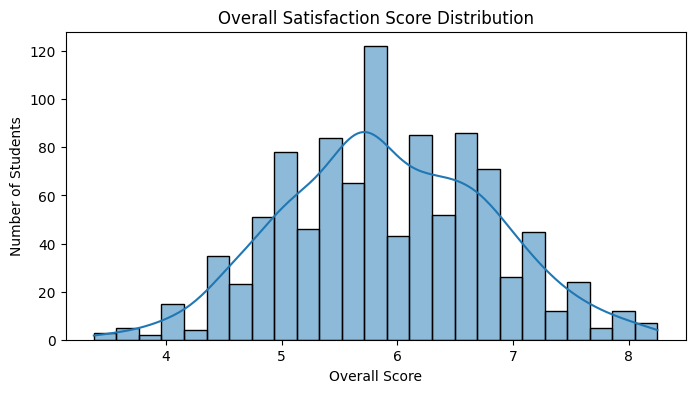

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df["OverallScore"], bins=25, kde=True)
plt.title("Overall Satisfaction Score Distribution")
plt.xlabel("Overall Score")
plt.ylabel("Number of Students")
plt.show()


In [7]:
question_means = df[rating_cols].mean().sort_values(ascending=False)
question_means


,0
WellVersed,7.497502
ExplainsClearly,6.081918
PrereqUse,5.942058
ProvidesSupport,5.662338
Structured,5.636364
RelevanceRecommend,5.598402
DoubtsSolved,5.474525
Depth,5.430569


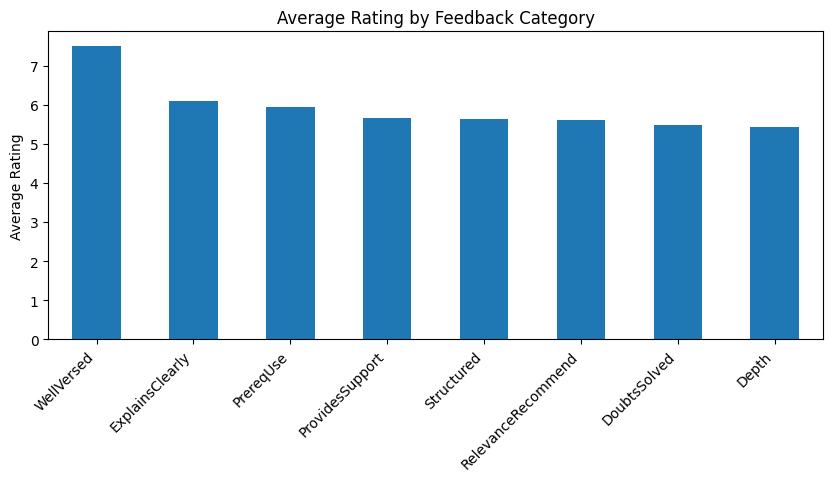

In [8]:
plt.figure(figsize=(10,4))
question_means.plot(kind="bar")
plt.title("Average Rating by Feedback Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.show()


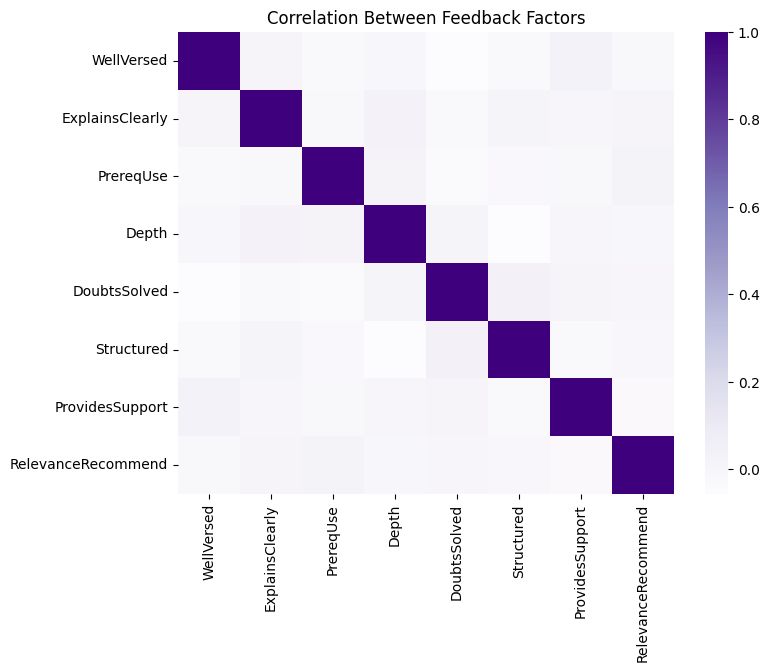

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df[rating_cols].corr(), cmap="Purples", annot=False)
plt.title("Correlation Between Feedback Factors")
plt.show()


In [10]:
top3 = question_means.head(3)
bottom3 = question_means.tail(3)

print("Top Strengths:")
for k, v in top3.items():
    print(f"- {k}: {v:.2f}")

print("\nNeeds Improvement:")
for k, v in bottom3.items():
    print(f"- {k}: {v:.2f}")


Top Strengths:
- WellVersed: 7.50
- ExplainsClearly: 6.08
- PrereqUse: 5.94

Needs Improvement:
- RelevanceRecommend: 5.60
- DoubtsSolved: 5.47
- Depth: 5.43


📊 Key Insights

Students rated WellVersed and ExplainsClearly the highest.

Lower ratings were observed in PrereqUse / Depth / DoubtsSolved.

Overall satisfaction score indicates moderate to high student satisfaction.

🛠 Recommendations

Improve prerequisite explanation before advanced topics.

Encourage more doubt-clearing sessions.

Maintain clarity and structured delivery, as these are strong areas.